In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/titanic/train.csv
/kaggle/input/competitions/titanic/test.csv
/kaggle/input/competitions/titanic/gender_submission.csv


#  Step 1: Business Understanding & Problem Definition

The objective of this project is to predict passenger survival aboard the Titanic using machine learning. We will frame this as a **binary classification problem** (Survived vs. Deceased). Our primary optimization metric will be **Accuracy**, aligning directly with the Kaggle leaderboard evaluation criteria.

#  Step 2: Data Gathering & Ingestion

We will begin by loading the raw training and testing datasets into memory. At this stage, we keep the datasets completely separate to ensure no future information modifies our baseline architecture.

In [2]:
import warnings
warnings.simplefilter(action='ignore', category=UserWarning)

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.svm import SVC
from lightgbm import LGBMClassifier

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, validation_curve
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score


In [4]:
train_data = pd.read_csv("/kaggle/input/competitions/titanic/train.csv")
test_data = pd.read_csv("/kaggle/input/competitions/titanic/test.csv")

# Step 3: Exploratory Data Analysis (EDA)

Before writing any data cleaning scripts, we perform a deep visual and statistical diagnostic check. We will inspect data shapes, missing value distributions, and feature correlations to unearth the underlying signal in the dataset.

In [5]:
train_data.shape

(891, 12)

In [6]:
train_data.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [7]:
train_data.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [8]:
train_data.tail(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [9]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [10]:
train_data.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [11]:
train_data.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


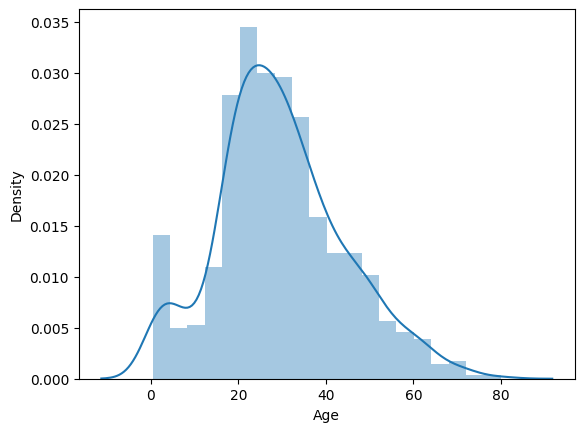

In [12]:
sns.distplot(train_data["Age"]);

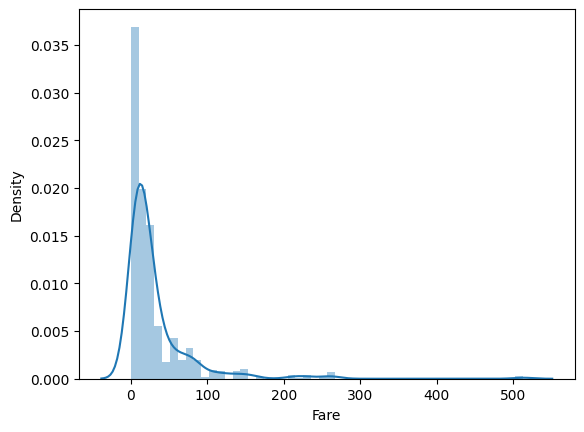

In [13]:
sns.distplot(train_data["Fare"]);

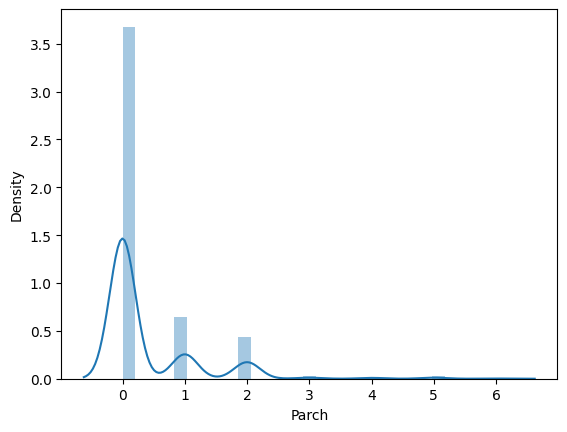

In [14]:
sns.distplot(train_data["Parch"]);

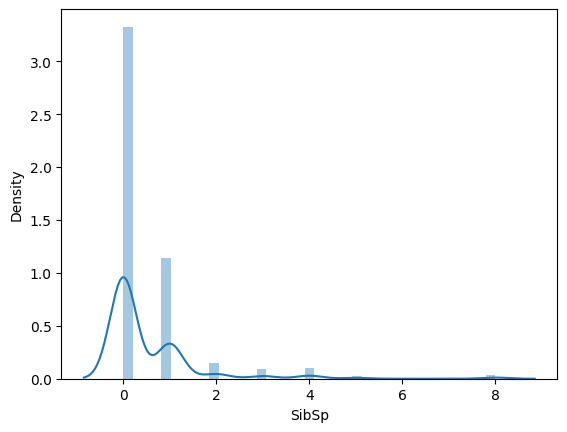

In [15]:
sns.distplot(train_data["SibSp"]);

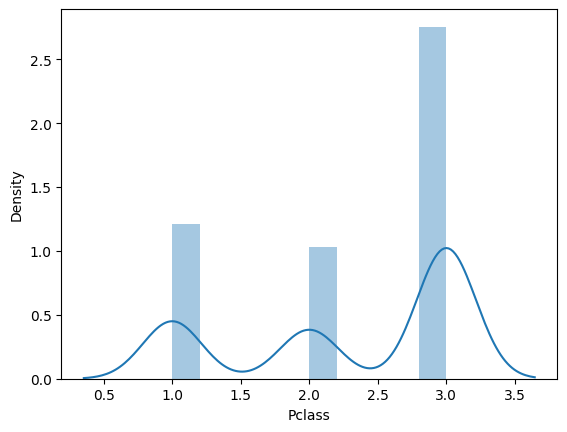

In [16]:
sns.distplot(train_data["Pclass"]);

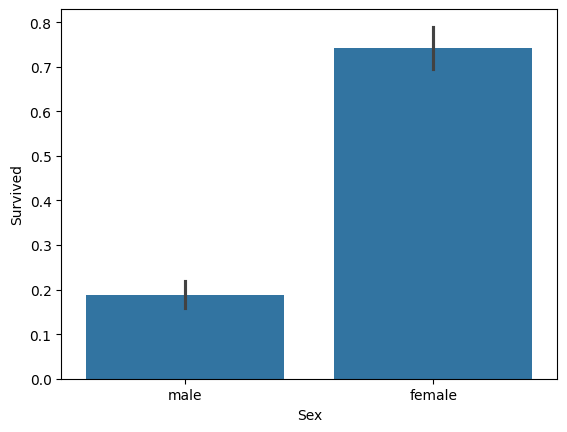

In [17]:
sns.barplot(data=train_data, x="Sex",y="Survived");

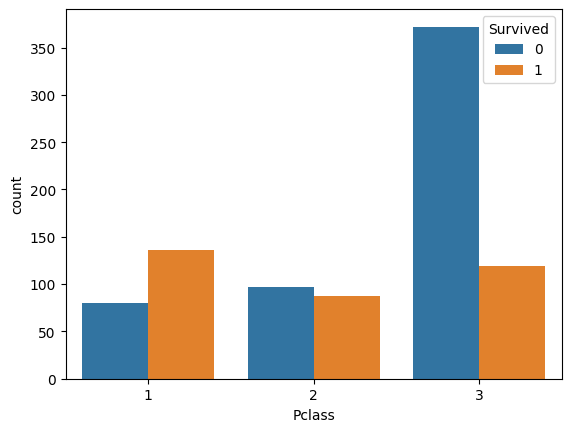

In [18]:
sns.countplot(train_data, x="Pclass", hue="Survived");

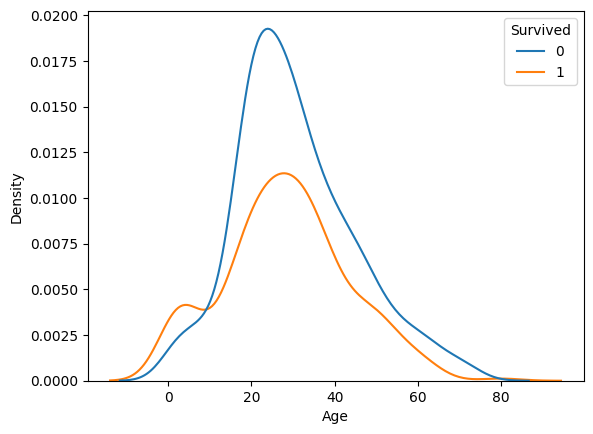

In [19]:
sns.kdeplot(data=train_data, x="Age", hue="Survived");

In [20]:
numerical_cols = train_data.select_dtypes("number").columns.to_list()
numerical_cols

['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']

<Axes: ylabel='Age'>

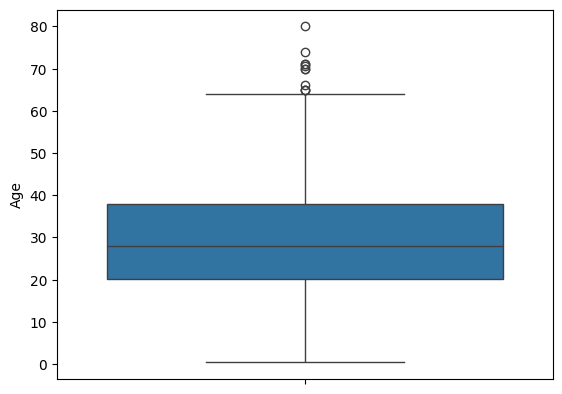

In [21]:
sns.boxplot(train_data["Age"])

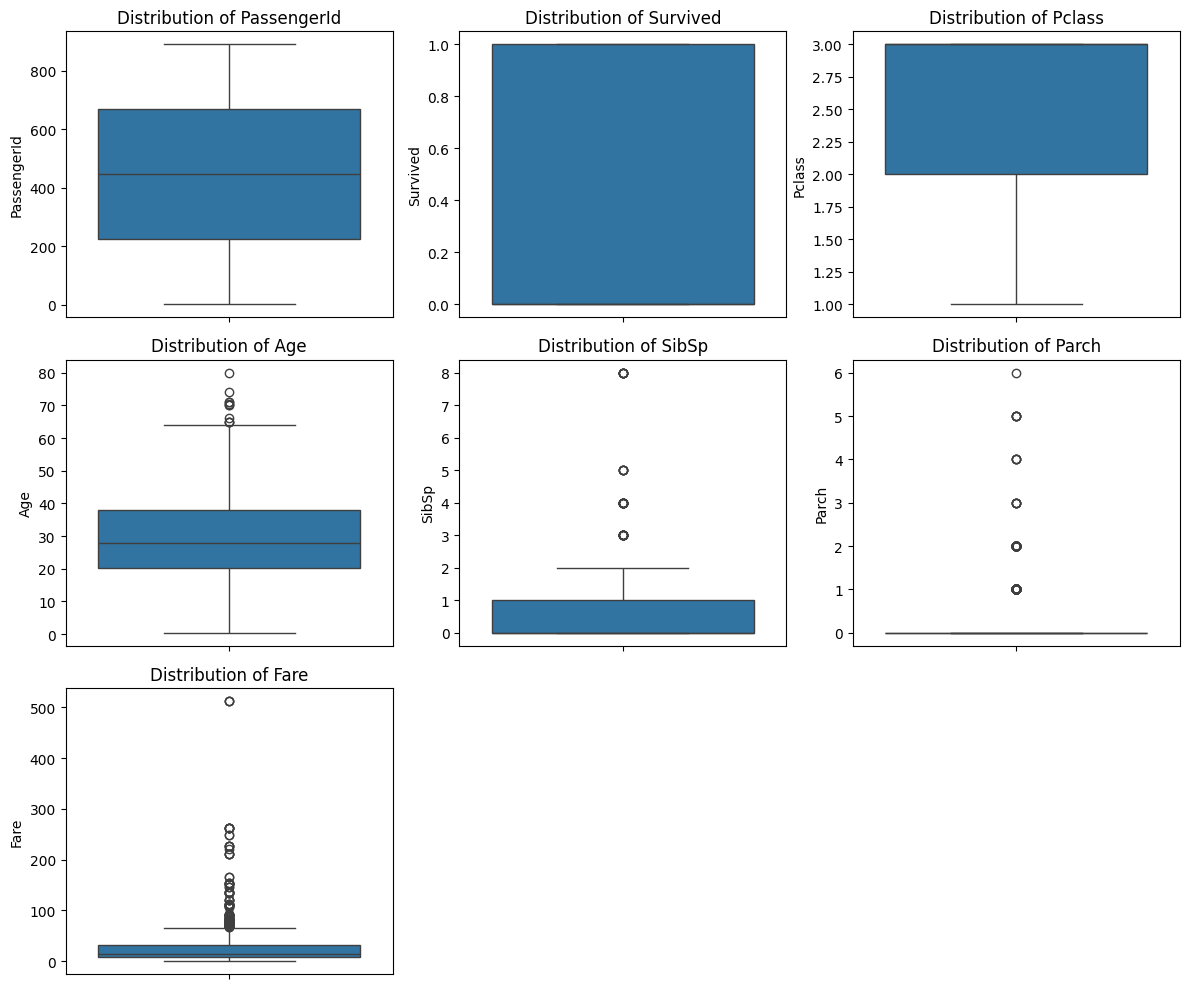

In [22]:
fig, axes = plt.subplots(3, 3, figsize=(12, 10))
axes_flat = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.boxplot(y=train_data[col], ax=axes_flat[i])
    axes_flat[i].set_title(f"Distribution of {col}")

for j in range(len(numerical_cols), len(axes_flat)):
    fig.delaxes(axes_flat[j])

plt.tight_layout()
plt.show()

# Step 4: Data Preprocessing & Feature Engineering

Based on our EDA findings, we establish our data-scrubbing strategy. Rather than manually altering the dataframes, we outline our plan for automated handling of missing values (NaNs), categorical encoding, and feature scaling to ensure clean mathematical convergence.

Raw data rarely tells the whole story. In this section, we extract highly localized signals from existing variables—such as parsing passenger prefixes into `Title` categories and calculating `TicketGroupSize`—to make hidden non-linear relationships explicit to our algorithms.

In [23]:
train_data

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [24]:
class AgeImputer (BaseEstimator, TransformerMixin):

    def __init__(self):
        self.medians_ = {}
        self.global_median_ = None

    def _clean_title_string(self, title):
        if title == "Mme": return "Mrs"
        elif title in ["Mlle", "Ms"]: return "Miss"
        elif title in ["Countess", "Lady", "Sir", "Don", "Jonkheer"]: return "Royalty"
        elif title in ["Col", "Major", "Capt", "Dr", "Rev"]: return "Professional"
        return title

    def fit(self, x, y=None):
        x_df = pd.DataFrame(x).copy()
        titles = x_df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
        x_df['Title'] = titles.apply(self._clean_title_string)
        self.medians_ = x_df.groupby("Title")['Age'].median().to_dict()
        self.global_median_ = x_df["Age"].median()
        return self


    def transform(self, x):
        x_df = pd.DataFrame(x).copy()
        titles = x_df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
        x_df['Title'] = titles.apply(self._clean_title_string)

        x_df["Age"] = x_df.apply(
            lambda row: row['Age'] if pd.notnull(row['Age'])
            else self.medians_.get(row['Title'], self.global_median_), 
            axis=1
        )
        return x_df

In [25]:
class EmbarkedImputer(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.mode_ = None
        
    def fit(self,x, y=None):
        x_df = pd.DataFrame(x).copy()
        self.mode_ = x_df["Embarked"].mode()[0]
        return self
        
    def transform(self,x):
        x_df = pd.DataFrame(x).copy()
        x_df["Embarked"] = x_df.apply(
            lambda row: row['Embarked'] if pd.notnull(row["Embarked"])
            else self.mode_,
            axis = 1
        )

        return x_df

In [26]:
class CabinImputer(BaseEstimator, TransformerMixin):

    def __init__(self):
        pass

    def fit(self, x, y=None):
        return self

    def transform(self, x):
        x_df = pd.DataFrame(x).copy()
        x_df['Cabin'] = x_df['Cabin'].notnull().astype(int)
        return x_df
        

In [27]:
class TicketImputer(BaseEstimator, TransformerMixin):

    def __init__(self):
        self.ticket_counts_ = {}

    def fit(self, x, y=None):
        x_df = pd.DataFrame(x).copy()
        self.ticket_counts_ = x_df["Ticket"].value_counts().to_dict()
        return self

    def transform(self, x):
        x_df = pd.DataFrame(x).copy()
        x_df['TicketGroupSize'] = x_df['Ticket'].map(self.ticket_counts_).fillna(1).astype(int)

        conditions = [
            (x_df['TicketGroupSize'] == 1),
            (x_df["TicketGroupSize"] >=2 ) & (x_df["TicketGroupSize"] <=4),
            (x_df["TicketGroupSize"] > 4)
        ]
        choices = ["Alone", "SmallGroup", "LargeGroup"]
        x_df["GroupType"] = np.select(conditions, choices, default="Alone")
        return x_df.drop(columns=["Name","PassengerId","Ticket"])

In [28]:
class LogFareTransformer(BaseEstimator, TransformerMixin):
    def __init__(self):
        pass

    def fit(self, x, y=None):
        return self 

    def transform(self, x):
        x_df = pd.DataFrame(x).copy()
        
        if 'Fare' in x_df.columns:
            x_df['Log Fare'] = np.log1p(x_df['Fare'])
            
        return x_df

In [29]:
preprocessor = ColumnTransformer(
    transformers= [
        ('cat', OneHotEncoder(sparse_output= False,handle_unknown='ignore'),['Sex','Title','GroupType', 'Embarked'])
    ],
    remainder = 'passthrough',
    force_int_remainder_cols=False 
)
preprocessor.set_output(transform="pandas")

ColumnTransformer(force_int_remainder_cols=False, remainder='passthrough',
                  transformers=[('cat',
                                 OneHotEncoder(handle_unknown='ignore',
                                               sparse_output=False),
                                 ['Sex', 'Title', 'GroupType', 'Embarked'])])

In [30]:
full_pipeline = Pipeline([
    ('age_imputer', AgeImputer()),
    ('embarked_imputer', EmbarkedImputer()),
    ('cabin_imputer', CabinImputer()),
    ('ticket_imputer', TicketImputer()),
    ('log_fare', LogFareTransformer()),
    ('encoding_and_scaling', preprocessor)
])


# Step 5: Data Splitting (The Leakage Shield)

To build a bulletproof validation system, we split our training records into distinct training and validation sets. This creates a critical boundary, ensuring our model is evaluated strictly on data it has never seen before.

In [31]:
X = train_data.drop(columns=['Survived'])
y = train_data['Survived']

In [32]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [33]:
X_train_processed = full_pipeline.fit_transform(X_train, y_train)

In [34]:
X_test_processed = full_pipeline.transform(X_test)

In [35]:
X_train_processed.head(5)

,cat__Sex_female,cat__Sex_male,cat__Title_Master,cat__Title_Miss,cat__Title_Mr,cat__Title_Mrs,cat__Title_Professional,cat__Title_Royalty,cat__GroupType_Alone,cat__GroupType_LargeGroup,...,cat__Embarked_Q,cat__Embarked_S,remainder__Pclass,remainder__Age,remainder__SibSp,remainder__Parch,remainder__Fare,remainder__Cabin,remainder__TicketGroupSize,remainder__Log Fare
331,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,...,0.0,1.0,1,45.5,0,0,28.5000,1,1,3.384390
733,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,...,0.0,1.0,2,23.0,0,0,13.0000,0,1,2.639057
382,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3,32.0,0,0,7.9250,0,1,2.188856
704,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3,26.0,1,0,7.8542,0,1,2.180892
813,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,1.0,3,6.0,4,2,31.2750,0,6,3.474293


In [36]:
print("Processed shape:", X_train_processed.shape)

Processed shape: (712, 22)


#  Step 6: Model Training & Selection (Spot-Checking)

Instead of guessing which algorithm works best, we launch a baseline model tournament. We train diverse model architectures—ranging from simple linear models to complex gradient-boosted trees—using default parameters evaluated via 5-Fold Cross-Validation.

In [37]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(random_state=42,max_depth= 5, min_samples_split = 5, n_estimators =  50),
    "Extra Trees": ExtraTreesClassifier(random_state=42),
    "Support Vector Machine": SVC(),
    "LightGBM": LGBMClassifier(random_state=42, verbose=-1)
}

for name, model in models.items():
    cv_scores = cross_val_score(model, X_train_processed, y_train, cv=5, scoring='accuracy')
    print(f"{name} Baseline CV Accuracy: {np.mean(cv_scores) * 100:.2f}%")

Logistic Regression Baseline CV Accuracy: 83.14%
Random Forest Baseline CV Accuracy: 83.70%
Extra Trees Baseline CV Accuracy: 80.07%
Support Vector Machine Baseline CV Accuracy: 67.55%
LightGBM Baseline CV Accuracy: 81.60%


# Step 7: Hyperparameter Tuning & Optimization

With our top-performing algorithms short-listed from the tournament, we deploy `GridSearchCV`. By systematically altering key algorithmic constraints, we seek to maximize predictive power while explicitly checking for overfitting.

In [38]:
lr_param_grid = {
    'C': [0.01, 0.1, 1.0, 10.0, 100.0],
    'penalty': ['l1', 'l2']
}

lr_grid_search = GridSearchCV(
    estimator=LogisticRegression(solver='liblinear', random_state=42), 
    param_grid=lr_param_grid, 
    cv=5, 
    scoring='accuracy', 
    n_jobs=-1
)

lr_grid_search.fit(X_train_processed, y_train)

print(f"Best LR CV Score: {lr_grid_search.best_score_:.4f}")
print(f"Best LR Params: {lr_grid_search.best_params_}")

Best LR CV Score: 0.8314
Best LR Params: {'C': 10.0, 'penalty': 'l2'}


In [39]:

rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 8, 12, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf_grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42), 
    param_grid=rf_param_grid, 
    cv=5, 
    scoring='accuracy', 
    n_jobs=-1
)

rf_grid_search.fit(X_train_processed, y_train)

print(f"Best RF CV Score: {rf_grid_search.best_score_:.4f}")
print(f"Best RF Params: {rf_grid_search.best_params_}")

Best RF CV Score: 0.8343
Best RF Params: {'max_depth': 12, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}


In [40]:
champion_rf = rf_grid_search.best_estimator_

y_train_pred = champion_rf.predict(X_train_processed)
train_accuracy = accuracy_score(y_train, y_train_pred)

cv_accuracy = rf_grid_search.best_score_

print("---  Model Generalization Diagnostics ---")
print(f"Training Accuracy:  {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")
print(f"Validation (CV) Accuracy: {cv_accuracy:.4f} ({cv_accuracy*100:.2f}%)")

gap = train_accuracy - cv_accuracy
print(f"Performance Gap:   {gap:.4f}")

---  Model Generalization Diagnostics ---
Training Accuracy:  0.9073 (90.73%)
Validation (CV) Accuracy: 0.8343 (83.43%)
Performance Gap:   0.0730


#  Step 8: Evaluation & Validation (Sanity Check)

In this phase, we look past simple accuracy scores. We plot training vs. testing curves to analyze the model's bias-variance tradeoff, ensuring our final champion has learned generalized structural rules rather than memorizing data noise.

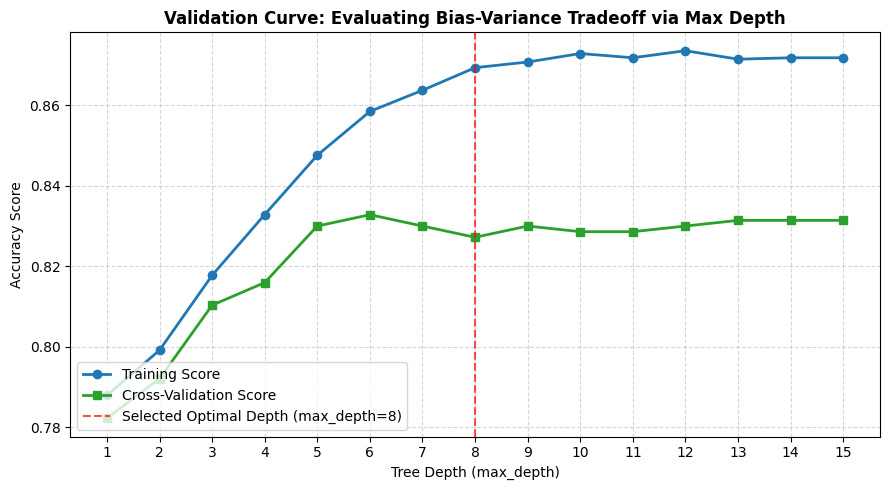

In [41]:

param_range = np.arange(1, 16)

train_scores, test_scores = validation_curve(
    estimator=RandomForestClassifier(min_samples_leaf=4, min_samples_split=2, n_estimators=300, random_state=42),
    X=X_train_processed,
    y=y_train,
    param_name="max_depth",
    param_range=param_range,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

plt.figure(figsize=(9, 5))
plt.plot(param_range, train_mean, label="Training Score", color="#1f77b4", marker="o", linewidth=2)
plt.plot(param_range, test_mean, label="Cross-Validation Score", color="#2ca02c", marker="s", linewidth=2)

plt.axvline(x=8, color="red", linestyle="--", alpha=0.7, label="Selected Optimal Depth (max_depth=8)")

plt.title("Validation Curve: Evaluating Bias-Variance Tradeoff via Max Depth", fontsize=12, fontweight='bold')
plt.xlabel("Tree Depth (max_depth)", fontsize=10)
plt.ylabel("Accuracy Score", fontsize=10)
plt.xticks(param_range)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="lower left")
plt.tight_layout()
plt.show()

#  Step 9: Model Deployment & Submission

With our optimized champion model completely locked down, we apply our transformation logic to the hidden Kaggle test data, and package our final inferences into a verified `submission.csv` file.

In [42]:
X_test_data_processed = full_pipeline.transform(test_data) 

final_predictions = champion_rf.predict(X_test_data_processed)

submission = pd.DataFrame({
    "PassengerId": test_data["PassengerId"],
    "Survived": final_predictions
})

submission.to_csv("submission.csv", index=False)
print(f"Success! 'submission.csv' generated with exactly {len(submission)} rows.")

Success! 'submission.csv' generated with exactly 418 rows.
